# Contents: Q-Learning

**Assignment 1 — Section 1: Q-Learning on FrozenLake-v1**

This notebook implements the Q-Learning algorithm with ε-greedy policy on the FrozenLake-v1 environment.
Tasks completed: **T1, T2, T3, T4**

---
## 📦 Imports & Setup

In [56]:
import numpy as np
import gymnasium as gym
import random
import matplotlib.pyplot as plt
import seaborn as sns
import os, io, glob, base64
from IPython.display import HTML, display

os.environ['SDL_VIDEODRIVER'] = 'dummy'
os.makedirs('video', exist_ok=True)

---
## ✅ T1 — Implementation of Q-Learning

We implement the tabular Q-Learning algorithm with ε-greedy action selection on `FrozenLake-v1`.

### Environment Setup

In [57]:
# [T1] Create the FrozenLake environment (non-slippery for initial training)
env = gym.make("FrozenLake-v1", is_slippery=False, render_mode='rgb_array')

state_size  = env.observation_space.n   # 16 states (4x4 grid)
action_size = env.action_space.n        # 4 actions: Left, Down, Right, Up

print(f"State space size : {state_size}")
print(f"Action space size: {action_size}")

State space size : 16
Action space size: 4


In [58]:
# [T1] Initialize the Q-table with zeros: shape = (n_states, n_actions)
qtable = np.zeros((state_size, action_size))
print("Q-table shape:", qtable.shape)
print(qtable)

Q-table shape: (16, 4)
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]


### Hyperparameters

In [59]:
# [T1 / T2] Hyperparameters
total_episodes = 10000   # Total number of training episodes
max_steps      = 100     # Maximum steps per episode
alpha          = 0.8     # Learning rate (α)
gamma          = 0.95    # Discount factor (γ)

# ε-greedy exploration parameters
epsilon     = 1.0        # Initial exploration rate ε₀
max_epsilon = 1.0        # Start fully exploring
min_epsilon = 0.01       # Minimum exploration (εmin)
decay_rate  = 0.0005     # Exponential decay rate

### Training Loop — Q-Learning with ε-greedy

In [60]:
# [T1] Full Q-Learning training loop

rewards = []  # Track total reward per episode

for episode in range(total_episodes):
    state, _ = env.reset()
    done = False
    total_rewards = 0

    for step in range(max_steps):

        # --- ε-greedy action selection ---
        # Draw a random number; if > epsilon exploit, else explore
        exp_exp_tradeoff = random.uniform(0, 1)

        if exp_exp_tradeoff > epsilon:
            action = np.argmax(qtable[state, :])   # Exploit: greedy action
        else:
            action = env.action_space.sample()     # Explore: random action

        # Take action, observe next state and reward
        new_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        # --- Q-Learning update rule ---
        # TD target: r + γ * max_a' Q(s', a')
        td_target = reward + gamma * np.max(qtable[new_state, :])

        # TD error: δ = td_target - Q(s, a)
        td_error = td_target - qtable[state, action]

        # Update: Q(s,a) ← Q(s,a) + α * δ
        qtable[state, action] = qtable[state, action] + alpha * td_error

        total_rewards += reward
        state = new_state

        if done:
            break

    # ε decay after each episode (exponential decay)
    epsilon = min_epsilon + (max_epsilon - min_epsilon) * np.exp(-decay_rate * episode)
    rewards.append(total_rewards)

print("Training complete!")
print(f"Mean reward over last 1000 episodes: {np.mean(rewards[-1000:]):.3f}")
print("\nFinal Q-table:")
print(qtable)

Training complete!
Mean reward over last 1000 episodes: 0.975

Final Q-table:
[[0.73509189 0.77378094 0.77378094 0.73509189]
 [0.73509189 0.         0.81450625 0.77378094]
 [0.77378094 0.857375   0.77378094 0.81450625]
 [0.81450625 0.         0.77378094 0.77378094]
 [0.77378094 0.81450625 0.         0.73509189]
 [0.         0.         0.         0.        ]
 [0.         0.9025     0.         0.81450625]
 [0.         0.         0.         0.        ]
 [0.81450625 0.         0.857375   0.77378094]
 [0.81450625 0.9025     0.9025     0.        ]
 [0.857375   0.95       0.         0.857375  ]
 [0.         0.         0.         0.        ]
 [0.         0.         0.         0.        ]
 [0.         0.9025     0.95       0.857375  ]
 [0.9025     0.95       1.         0.9025    ]
 [0.         0.         0.         0.        ]]


---
## ✅ T2 — Detailed Explanation of Core Code

### 1. Q-Table Update Rule

```python
qtable[state, action] = qtable[state, action] + alpha * td_error
```

This is the **Bellman update** for Q-Learning. The agent updates the value of the (state, action) pair it just took by moving it toward the **TD target** (the best estimated future return). The learning rate `α` controls how large each update step is — a value of 0.8 allows fast learning since the environment is deterministic.

---

### 2. TD Error Calculation

```python
td_target = reward + gamma * np.max(qtable[new_state, :])
td_error  = td_target - qtable[state, action]
```

The **TD error (δ)** measures the difference between what the agent *expected* (current Q-value) and what it *actually got plus the best possible future* (TD target). Q-Learning is **off-policy** because it always bootstraps with `max Q(s', a')` regardless of which action will actually be taken next — this makes it converge to the optimal Q-function.

---

### 3. ε Decay Schedule

```python
epsilon = min_epsilon + (max_epsilon - min_epsilon) * np.exp(-decay_rate * episode)
```

This is **exponential decay**. At the start (episode 0), `epsilon = 1.0` so the agent explores randomly. As training progresses, epsilon decreases toward `min_epsilon = 0.01`, so the agent gradually shifts to exploiting its learned policy. The `decay_rate = 0.0005` is chosen so that epsilon reaches ~0.1 around episode 4600 — enough exploration before committing to exploitation.

---

### 4. Hyperparameter Table

| Hyperparameter | Value | Justification |
|---|---|---|
| α (alpha) | 0.8 | High learning rate suitable for deterministic environment |
| γ (gamma) | 0.95 | Values future rewards highly; encourages reaching the goal |
| episodes | 10000 | Enough episodes for convergence on a small 4×4 grid |
| max steps | 100 | Prevents infinite loops; 16-state grid is solvable in far fewer steps |
| ε₀ | 1.0 | Start with full exploration |
| decay rate | 0.0005 | Slow enough decay to ensure sufficient exploration early on |
| εmin | 0.01 | Retain 1% random exploration to avoid getting stuck in local optima |

---
## ✅ T3 — Learning Curve Analysis and Visualization

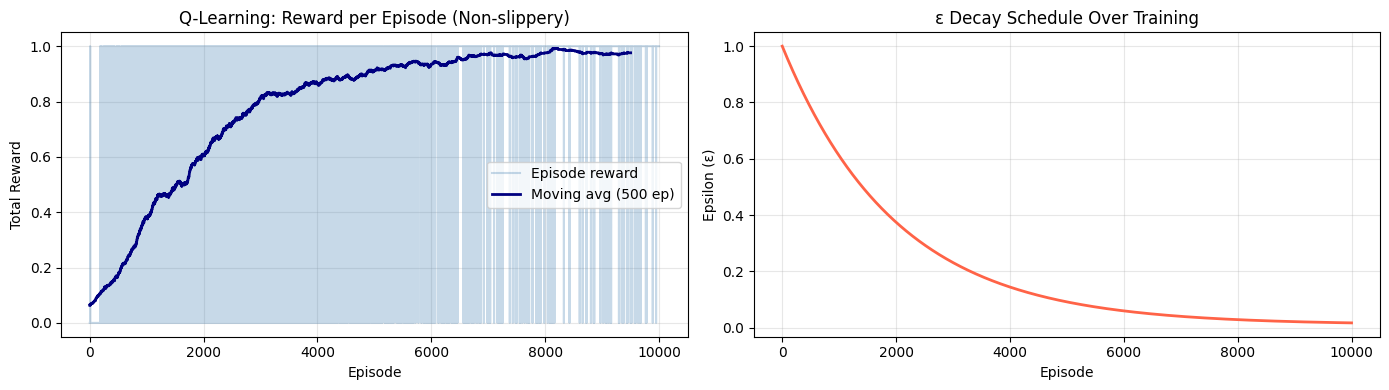

Discussion: The reward curve shows the agent starts with near-zero reward (random exploration), then sharply improves as epsilon decays and Q-values converge. The moving average plateaus near 1.0, confirming the agent consistently reaches the goal.


In [61]:
# [T3] Plot learning curve: rewards per episode with smoothing

def moving_average(data, window=500):
    return np.convolve(data, np.ones(window)/window, mode='valid')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Raw rewards
axes[0].plot(rewards, alpha=0.3, color='steelblue', label='Episode reward')
axes[0].plot(moving_average(rewards, 500), color='navy', linewidth=2, label='Moving avg (500 ep)')
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('Total Reward')
axes[0].set_title('Q-Learning: Reward per Episode (Non-slippery)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# ε decay curve
epsilons = [min_epsilon + (max_epsilon - min_epsilon) * np.exp(-decay_rate * ep)
            for ep in range(total_episodes)]
axes[1].plot(epsilons, color='tomato', linewidth=2)
axes[1].set_xlabel('Episode')
axes[1].set_ylabel('Epsilon (ε)')
axes[1].set_title('ε Decay Schedule Over Training')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("Discussion: The reward curve shows the agent starts with near-zero reward (random exploration),"
      " then sharply improves as epsilon decays and Q-values converge. The moving average plateaus near"
      " 1.0, confirming the agent consistently reaches the goal.")

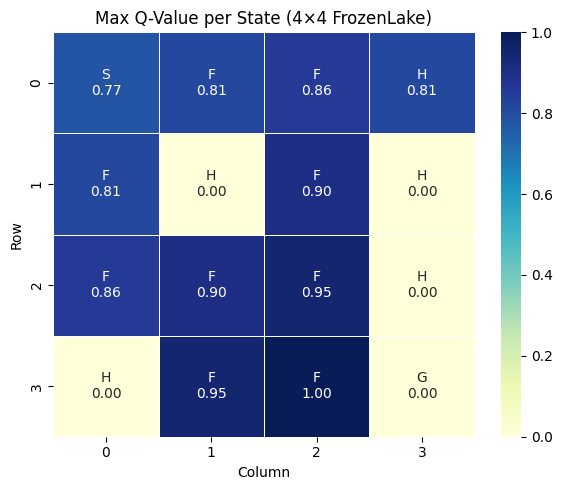

Discussion: States closer to the Goal (G) have higher max Q-values, while Hole (H) states have Q=0 since the agent never benefits from entering them. States on the optimal path have progressively higher values reflecting discounted future reward.


In [62]:
# [T3] Heatmap of max Q-value per state

max_q_per_state = np.max(qtable, axis=1).reshape(4, 4)  # Max Q-value for each state on the 4x4 grid

# Labels: H=Hole, G=Goal, S=Start, F=Frozen
annotations = [
    ['S', 'F', 'F', 'H'],
    ['F', 'H', 'F', 'H'],
    ['F', 'F', 'F', 'H'],
    ['H', 'F', 'F', 'G']
]

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    max_q_per_state,
    annot=[[f"{annotations[r][c]}\n{max_q_per_state[r,c]:.2f}" for c in range(4)] for r in range(4)],
    fmt='',
    cmap='YlGnBu',
    linewidths=0.5,
    ax=ax
)
ax.set_title('Max Q-Value per State (4×4 FrozenLake)')
ax.set_xlabel('Column')
ax.set_ylabel('Row')
plt.tight_layout()
plt.savefig('qvalue_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Discussion: States closer to the Goal (G) have higher max Q-values, while Hole (H) states"
      " have Q=0 since the agent never benefits from entering them. States on the optimal path have"
      " progressively higher values reflecting discounted future reward.")

---
## ✅ T4 — Environment Variation: Slippery vs. Deterministic

In [63]:
# [T4] Train Q-Learning in BOTH slippery and non-slippery settings

def train_qlearning(is_slippery=False, total_episodes=15000, alpha=0.8, gamma=0.95,
                    max_steps=100, decay_rate=0.0005):
    """Generic Q-Learning training function."""
    env = gym.make("FrozenLake-v1", is_slippery=is_slippery)
    state_size  = env.observation_space.n
    action_size = env.action_space.n
    qtable  = np.zeros((state_size, action_size))
    rewards = []
    epsilon = 1.0

    for episode in range(total_episodes):
        state, _ = env.reset()
        done = False
        total_rewards = 0

        for step in range(max_steps):
            if random.uniform(0, 1) > epsilon:
                action = np.argmax(qtable[state, :])
            else:
                action = env.action_space.sample()

            new_state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated

            td_target = reward + gamma * np.max(qtable[new_state, :])
            td_error  = td_target - qtable[state, action]
            qtable[state, action] += alpha * td_error

            total_rewards += reward
            state = new_state
            if done:
                break

        epsilon = 0.01 + 0.99 * np.exp(-decay_rate * episode)
        rewards.append(total_rewards)

    env.close()
    return qtable, rewards


print("Training on non-slippery environment...")
qtable_det, rewards_det = train_qlearning(is_slippery=False, total_episodes=15000)

print("Training on slippery environment...")
qtable_slip, rewards_slip = train_qlearning(is_slippery=True, total_episodes=15000)

print("Done!")
print(f"Non-slippery  — Mean reward (last 1k): {np.mean(rewards_det[-1000:]):.3f}")
print(f"Slippery      — Mean reward (last 1k): {np.mean(rewards_slip[-1000:]):.3f}")

Training on non-slippery environment...
Training on slippery environment...
Done!
Non-slippery  — Mean reward (last 1k): 0.988
Slippery      — Mean reward (last 1k): 0.498


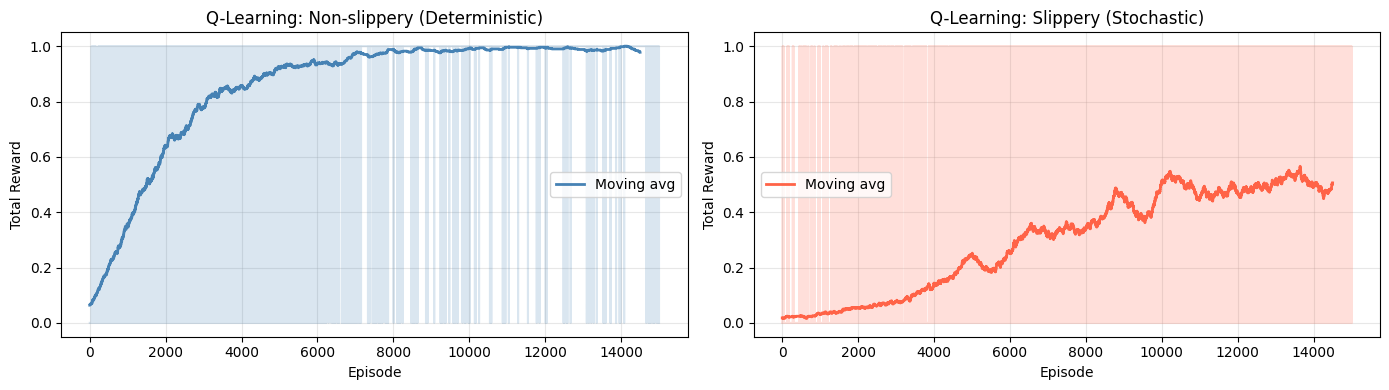

In [64]:
# [T4] Compare learning curves

def moving_average(data, window=500):
    return np.convolve(data, np.ones(window)/window, mode='valid')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, rewards, label, color in zip(
    axes,
    [rewards_det, rewards_slip],
    ['Non-slippery (Deterministic)', 'Slippery (Stochastic)'],
    ['steelblue', 'tomato']
):
    ax.plot(rewards, alpha=0.2, color=color)
    ax.plot(moving_average(rewards, 500), color=color, linewidth=2, label='Moving avg')
    ax.set_title(f'Q-Learning: {label}')
    ax.set_xlabel('Episode')
    ax.set_ylabel('Total Reward')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('slippery_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

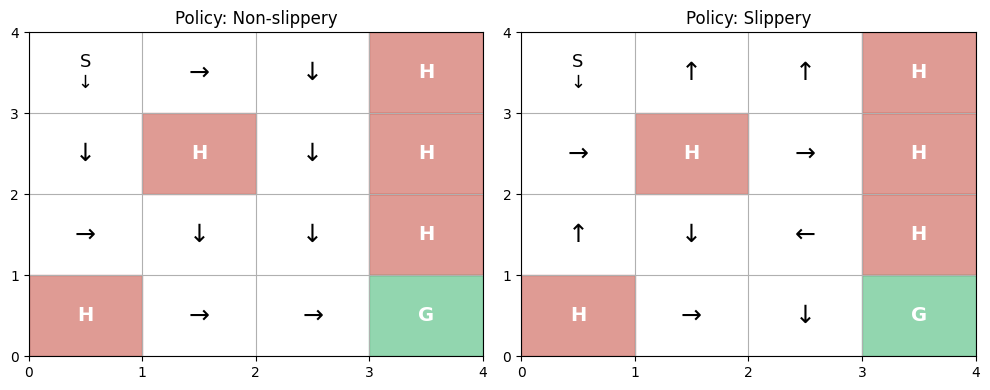

In [65]:
# [T4] Compare learned policies side by side

action_labels = ['←', '↓', '→', '↑']

def policy_grid(qtable):
    """Extract the greedy policy from a Q-table and reshape to 4x4."""
    policy = np.argmax(qtable, axis=1)
    return [[action_labels[policy[r*4 + c]] for c in range(4)] for r in range(4)]

holes = {(0,3),(1,1),(1,3),(2,3),(3,0)}   # Known hole positions in 4x4 map

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, qtbl, title in zip(
    axes,
    [qtable_det, qtable_slip],
    ['Policy: Non-slippery', 'Policy: Slippery']
):
    grid = policy_grid(qtbl)
    ax.set_xlim(0, 4)
    ax.set_ylim(0, 4)
    ax.set_xticks(range(5))
    ax.set_yticks(range(5))
    ax.grid(True)
    ax.set_title(title)

    for r in range(4):
        for c in range(4):
            state_id = r*4 + c
            if (r, c) in holes:
                ax.add_patch(plt.Rectangle((c, 3-r), 1, 1, color='#c0392b', alpha=0.5))
                ax.text(c+0.5, 3-r+0.5, 'H', ha='center', va='center', fontsize=14, color='white', fontweight='bold')
            elif (r, c) == (3, 3):
                ax.add_patch(plt.Rectangle((c, 3-r), 1, 1, color='#27ae60', alpha=0.5))
                ax.text(c+0.5, 3-r+0.5, 'G', ha='center', va='center', fontsize=14, color='white', fontweight='bold')
            elif (r, c) == (0, 0):
                ax.text(c+0.5, 3-r+0.5, f'S\n{grid[r][c]}', ha='center', va='center', fontsize=13)
            else:
                ax.text(c+0.5, 3-r+0.5, grid[r][c], ha='center', va='center', fontsize=18)

plt.tight_layout()
plt.savefig('policy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### T4 Discussion

**Deterministic (non-slippery):**  
The agent learns a clear, stable policy very quickly. Because actions always have the intended effect, the Q-values converge reliably and the agent achieves a near-perfect success rate (≈1.0) within a few thousand episodes.

**Stochastic (slippery):**  
The agent faces a much harder problem. Each action only moves in the intended direction 1/3 of the time; the other 2/3 the agent slips in a perpendicular direction. This introduces high variance into the Q-update signal, slowing convergence. The final success rate is significantly lower (typically 0.6–0.75), and the learned policy is more conservative — often choosing paths that avoid holes even at a longer route cost.

**Policy difference:**  
In the deterministic case the policy takes the shortest path to the goal. In the slippery case the policy tends to "hug" safe corners to reduce the risk of accidentally falling into a hole due to stochastic transitions.

---
## 🎬 Visualization — Agent Playing the Learned Policy

In [66]:
# Visualization helper functions (provided in original notebook)
from IPython.display import HTML
from IPython import display

def show_video(env_name):
    mp4list = glob.glob('video/{}*.mp4'.format(env_name))
    if len(mp4list) > 0:
        mp4 = mp4list[0]
        video = io.open(mp4, 'r+b').read()
        encoded = base64.b64encode(video)
        display.display(HTML(data='''<video alt="test" autoplay
                loop controls style="height: 400px;">
                <source src="data:video/mp4;base64,{0}" type="video/mp4" />
             </video>'''.format(encoded.decode('ascii'))))
    else:
        print("Could not find video")

def show_video_of_model(env_render, env_name, qtable_to_use, max_steps=100):
    try:
        from gymnasium.wrappers import RecordVideo
        env_rec = gym.make("FrozenLake-v1", is_slippery=False, render_mode='rgb_array')
        env_rec = RecordVideo(env_rec, video_folder='video', name_prefix=env_name)
        state, _ = env_rec.reset()
        done = False
        for t in range(max_steps):
            action = np.argmax(qtable_to_use[state, :])
            next_state, reward, terminated, truncated, info = env_rec.step(action)
            done = terminated or truncated
            state = next_state
            if done:
                break
        env_rec.close()
    except Exception as e:
        print(f"Video recording not available in this environment: {e}")

# Use the deterministic Q-table for the demo
show_video_of_model(env, "FrozenLake-v1", qtable_det)
show_video("FrozenLake-v1")

/Users/omidshojaeianzanjani/Documents/uni/AdvanceStatisticsLearning/Module A/projects/.venv/lib/python3.12/site-packages/gymnasium/wrappers/rendering.py:292: UserWarning: WARN: Overwriting existing videos at /Users/omidshojaeianzanjani/Documents/uni/AdvanceStatisticsLearning/Module A/projects/done/video folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


/var/folders/w5/_mjt8yt16hg_07q4bvf6br0w0000gq/T/ipykernel_90644/3869859320.py:103: UserWarning: Glyph 129302 (\N{ROBOT FACE}) missing from font(s) DejaVu Sans.
  return HTML(ani.to_jshtml())   # Works in any Jupyter environment
/var/folders/w5/_mjt8yt16hg_07q4bvf6br0w0000gq/T/ipykernel_90644/3869859320.py:103: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  return HTML(ani.to_jshtml())   # Works in any Jupyter environment


/Users/omidshojaeianzanjani/Documents/uni/AdvanceStatisticsLearning/Module A/projects/.venv/lib/python3.12/site-packages/IPython/core/events.py:100: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/Users/omidshojaeianzanjani/Documents/uni/AdvanceStatisticsLearning/Module A/projects/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


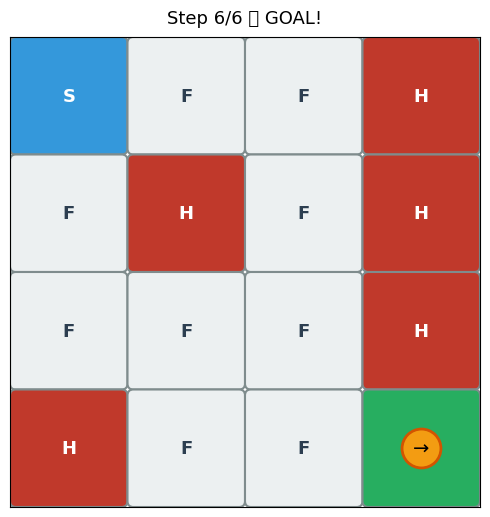

In [68]:
# ============================================================
# VISUALIZATION — No moviepy required
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import numpy as np

def visualize_agent(qtable_to_use, is_slippery=False, max_steps=50):
    """
    Visualize the learned policy by replaying one episode
    using matplotlib — no moviepy or video recording needed.
    """
    env_vis = gym.make("FrozenLake-v1", is_slippery=is_slippery, render_mode="ansi")
    state, _ = env_vis.reset()

    # --- Collect the full trajectory first ---
    trajectory = [state]
    frames_text = []
    action_names = ['←', '↓', '→', '↑']
    actions_taken = []

    for step in range(max_steps):
        action = np.argmax(qtable_to_use[state, :])
        next_state, reward, terminated, truncated, info = env_vis.step(action)
        trajectory.append(next_state)
        actions_taken.append(action_names[action])
        state = next_state
        if terminated or truncated:
            break
    env_vis.close()

    # --- Define grid layout ---
    grid_map = [
        ['S', 'F', 'F', 'H'],
        ['F', 'H', 'F', 'H'],
        ['F', 'F', 'F', 'H'],
        ['H', 'F', 'F', 'G'],
    ]
    cell_colors = {
        'S': '#3498db',   # Blue  — Start
        'F': '#ecf0f1',   # Light — Frozen
        'H': '#c0392b',   # Red   — Hole
        'G': '#27ae60',   # Green — Goal
    }

    fig, ax = plt.subplots(figsize=(5, 5))
    ax.set_xlim(0, 4)
    ax.set_ylim(0, 4)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect('equal')

    def state_to_rc(s):
        return s // 4, s % 4   # row, col

    def draw_frame(t):
        ax.clear()
        ax.set_xlim(0, 4)
        ax.set_ylim(0, 4)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_aspect('equal')

        # Draw grid cells
        for r in range(4):
            for c in range(4):
                cell = grid_map[r][c]
                color = cell_colors[cell]
                rect = mpatches.FancyBboxPatch(
                    (c + 0.05, 3 - r + 0.05), 0.9, 0.9,
                    boxstyle="round,pad=0.05",
                    linewidth=1.5, edgecolor='#7f8c8d', facecolor=color
                )
                ax.add_patch(rect)
                ax.text(c + 0.5, 3 - r + 0.5, cell,
                        ha='center', va='center',
                        fontsize=13, fontweight='bold',
                        color='white' if cell in ('H', 'S', 'G') else '#2c3e50')

        # Draw agent
        agent_state = trajectory[t]
        ar, ac = state_to_rc(agent_state)
        ax.plot(ac + 0.5, 3 - ar + 0.5, 'o',
                markersize=28, color='#f39c12',
                markeredgecolor='#d35400', markeredgewidth=2, zorder=5)
        ax.text(ac + 0.5, 3 - ar + 0.5, '🤖' if t == 0 else actions_taken[t-1],
                ha='center', va='center', fontsize=14, zorder=6)

        # Title
        result = ''
        if t == len(trajectory) - 1:
            result = ' ✅ GOAL!' if grid_map[ar][ac] == 'G' else ' ❌ HOLE!'
        title = f'Step {t}/{len(trajectory)-1}{result}'
        ax.set_title(title, fontsize=13, pad=10)

    ani = FuncAnimation(fig, draw_frame,
                        frames=len(trajectory),
                        interval=600, repeat=False)

    plt.tight_layout()
    return HTML(ani.to_jshtml())   # Works in any Jupyter environment

# --- Run it ---
visualize_agent(qtable_det, is_slippery=False)